In [1]:
# Install interactive BI & visualization libraries for Google Colab
!pip install -q plotly pygwalker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.2/956.2 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 90.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files

# Global aesthetic styling
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

print("Upload your Global EV Dataset (.csv or .xlsx):")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(io.BytesIO(uploaded[file_name])) if file_name.endswith('.csv') else pd.read_excel(io.BytesIO(uploaded[file_name]))

# Standardize column headers
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Data Type Corrections
if 'value' in df.columns:
    df['value'] = pd.to_numeric(df['value'], errors='coerce')

if 'year' in df.columns:
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

# Clean string values across categorical attributes
cat_cols = ['region', 'category', 'parameter', 'mode', 'powertrain', 'unit']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

print(f"\nSuccessfully Ingested: {df.shape[0]:,} Records | {df.shape[1]} Attributes")
df.head()

Upload your Global EV Dataset (.csv or .xlsx):


Saving IEA Global EV Data 2024.csv to IEA Global EV Data 2024.csv

Successfully Ingested: 12,654 Records | 8 Attributes


,region,category,parameter,mode,powertrain,year,unit,value
0,Australia,Historical,EV stock share,Cars,EV,2011,percent,0.00039
1,Australia,Historical,EV sales share,Cars,EV,2011,percent,0.00650
2,Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.00000
3,Australia,Historical,EV stock,Cars,BEV,2011,Vehicles,49.00000
4,Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,220.00000


In [3]:
# Executive Global EV Market KPI Scorecard
total_records = len(df)
latest_year = df['year'].max() if 'year' in df.columns else "N/A"
regions_count = df['region'].nunique() if 'region' in df.columns else 0

# EV Sales & Stock Totals (Filtering for world or global aggregated metrics if present)
ev_sales_latest = df[(df['parameter'].str.contains('sales', case=False, na=False)) & (df['year'] == latest_year)]['value'].sum() if 'parameter' in df.columns else np.nan
ev_stock_latest = df[(df['parameter'].str.contains('stock', case=False, na=False)) & (df['year'] == latest_year)]['value'].sum() if 'parameter' in df.columns else np.nan

kpi_summary = pd.DataFrame({
    'Global EV Industry Metric': [
        'Total Dataset Records',
        'Latest Data Year',
        'Unique Regions / Countries Analyzed',
        f'Latest Year ({latest_year}) Total EV Sales Volume',
        f'Latest Year ({latest_year}) Total EV Stock Volume'
    ],
    'Value': [
        f"{total_records:,}",
        f"{latest_year}",
        f"{regions_count}",
        f"{ev_sales_latest:,.0f}" if pd.notna(ev_sales_latest) else "N/A",
        f"{ev_stock_latest:,.0f}" if pd.notna(ev_stock_latest) else "N/A"
    ]
})

print("=== EXECUTIVE GLOBAL EV MARKET KPI SCORECARD ===")
kpi_summary

=== EXECUTIVE GLOBAL EV MARKET KPI SCORECARD ===


,Global EV Industry Metric,Value
0,Total Dataset Records,"12,654"
1,Latest Data Year,2035
2,Unique Regions / Countries Analyzed,54
3,Latest Year (2035) Total EV Sales Volume,"287,449,581"
4,Latest Year (2035) Total EV Stock Volume,"2,242,942,275"


In [4]:
# 1. Global EV Sales Growth Trajectory by Region Over Time
import plotly.express as px

sales_df = df[df['parameter'].str.contains('sales', case=False, na=False)].copy()

if not sales_df.empty and all(col in sales_df.columns for col in ['year', 'value', 'region']):
    # Filter out aggregated 'World' or 'EU27' if evaluating top individual countries, or keep for macro trends
    top_regions = sales_df.groupby('region')['value'].sum().nlargest(10).index
    df_filtered_sales = sales_df[sales_df['region'].isin(top_regions)]

    fig_sales_trend = px.line(
        df_filtered_sales,
        x='year',
        y='value',
        color='region',
        markers=True,
        title='<b>Global EV Sales Growth Trajectory by Top Regions</b>',
        labels={'value': 'EV Sales', 'year': 'Year', 'region': 'Region / Country'},
        template='plotly_white'
    )
    fig_sales_trend.update_layout(height=550)
    fig_sales_trend.show()

In [5]:
# 2. Powertrain Adoption Breakdown: BEV vs. PHEV Share by Vehicle Mode
import plotly.express as px

if all(col in df.columns for col in ['powertrain', 'mode', 'value', 'parameter']):
    powertrain_df = df[
        (df['parameter'].str.contains('sales|stock', case=False, na=False)) &
        (df['powertrain'].isin(['BEV', 'PHEV', 'FCEV', 'EV']))
    ].groupby(['mode', 'powertrain'])['value'].sum().reset_index()

    fig_powertrain = px.bar(
        powertrain_df,
        x='mode',
        y='value',
        color='powertrain',
        barmode='group',
        title='<b>EV Powertrain Distribution (BEV vs. PHEV vs. FCEV) Across Vehicle Modes</b>',
        labels={'value': 'Volume', 'mode': 'Vehicle Mode', 'powertrain': 'Powertrain Type'},
        template='plotly_white',
        color_discrete_sequence=px.colors.qualitative.Bold
    )
    fig_powertrain.update_layout(height=500)
    fig_powertrain.show()

In [6]:
# 3. Global EV Ecosystem Hierarchy (Region → Category → Mode → Powertrain)
if all(col in df.columns for col in ['region', 'category', 'mode', 'powertrain', 'value']):
    # Filter for top regions to maintain visual clarity
    top_5_regions = df.groupby('region')['value'].sum().nlargest(5).index
    df_sunburst = df[df['region'].isin(top_5_regions)].dropna(subset=['region', 'category', 'mode', 'powertrain', 'value'])

    fig_sunburst = px.sunburst(
        df_sunburst,
        path=['region', 'category', 'mode', 'powertrain'],
        values='value',
        color='category',
        title='<b>Global EV Market Hierarchy: Region → Category → Mode → Powertrain</b>',
        template='plotly_white'
    )
    fig_sunburst.update_layout(height=650)
    fig_sunburst.show()

In [7]:
# 1. Geographic EV Adoption Footprint (Global Choropleth Map)
import plotly.express as px

if all(col in df.columns for col in ['region', 'parameter', 'year', 'value']):
    latest_year = df['year'].max()
    map_df = df[
        (df['year'] == latest_year) &
        (df['parameter'].str.contains('sales', case=False, na=False)) &
        (~df['region'].str.lower().isin(['world', 'eu27', 'europe', 'rest of world', 'other']))
    ].groupby('region')['value'].sum().reset_index()

    fig_map = px.choropleth(
        map_df,
        locations='region',
        locationmode='country names',
        color='value',
        hover_name='region',
        color_continuous_scale='Viridis',
        title=f'<b>Geographic EV Sales Distribution Across Nations ({latest_year})</b>',
        labels={'value': 'EV Sales Volume', 'region': 'Country / Region'},
        template='plotly_white'
    )
    fig_map.update_layout(height=550)
    fig_map.show()

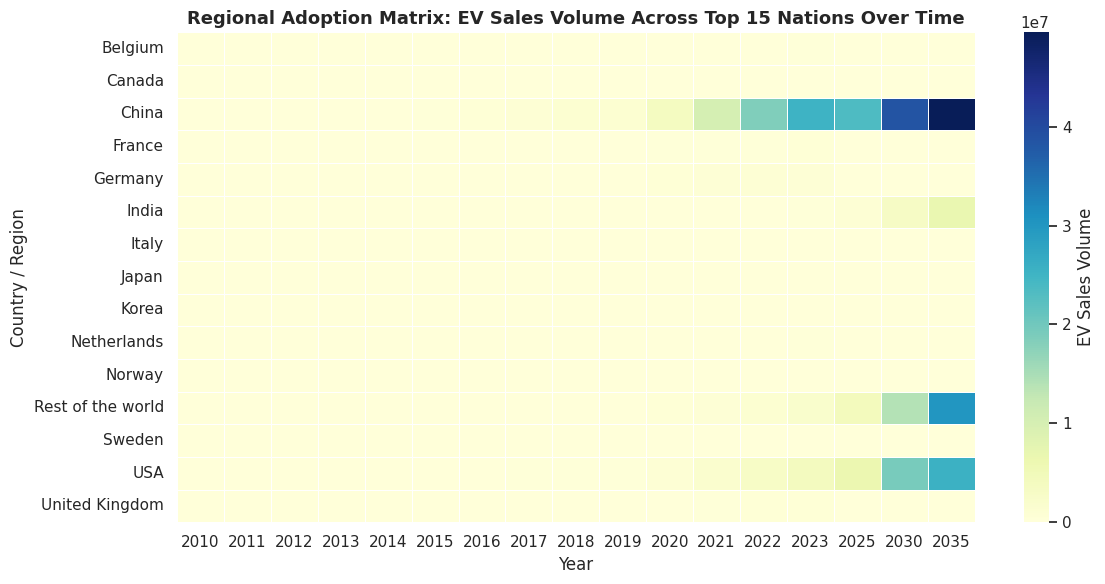

In [8]:
# 2. Regional Adoption Matrix: EV Growth Heatmap (Top 15 Countries vs. Years)
import seaborn as sns
import matplotlib.pyplot as plt

if all(col in df.columns for col in ['region', 'year', 'value', 'parameter']):
    sales_df = df[
        (df['parameter'].str.contains('sales', case=False, na=False)) &
        (~df['region'].str.lower().isin(['world', 'eu27', 'europe', 'rest of world']))
    ]

    top_countries = sales_df.groupby('region')['value'].sum().nlargest(15).index
    heatmap_data = sales_df[sales_df['region'].isin(top_countries)].pivot_table(
        index='region',
        columns='year',
        values='value',
        aggfunc='sum'
    ).fillna(0)

    plt.figure(figsize=(12, 6))
    sns.heatmap(
        heatmap_data,
        cmap='YlGnBu',
        annot=False,
        linewidths=0.5,
        cbar_kws={'label': 'EV Sales Volume'}
    )
    plt.title('Regional Adoption Matrix: EV Sales Volume Across Top 15 Nations Over Time', fontweight='bold', fontsize=13)
    plt.xlabel('Year')
    plt.ylabel('Country / Region')
    plt.tight_layout()
    plt.show()

In [9]:
# 3. Global Technology Transition: BEV vs. PHEV Market Share Trajectory (100% Stacked Area)
import plotly.express as px

if all(col in df.columns for col in ['powertrain', 'year', 'value', 'parameter']):
    bev_phev_df = df[
        (df['parameter'].str.contains('sales', case=False, na=False)) &
        (df['powertrain'].isin(['BEV', 'PHEV']))
    ].groupby(['year', 'powertrain'])['value'].sum().reset_index()

    # Calculate yearly percentage share
    yearly_totals = bev_phev_df.groupby('year')['value'].transform('sum')
    bev_phev_df['share_percentage'] = np.where(yearly_totals > 0, (bev_phev_df['value'] / yearly_totals) * 100, 0)

    fig_tech_shift = px.area(
        bev_phev_df,
        x='year',
        y='share_percentage',
        color='powertrain',
        title='<b>Global Technology Shift: BEV vs. PHEV Market Share Evolution (%)</b>',
        labels={'share_percentage': 'Market Share (%)', 'year': 'Year', 'powertrain': 'Powertrain Type'},
        template='plotly_white',
        color_discrete_map={'BEV': '#00b894', 'PHEV': '#0984e3'}
    )
    fig_tech_shift.update_layout(height=500, yaxis_range=[0, 100])
    fig_tech_shift.show()

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ---------------------------------------------------------
# 1. Data Aggregation & Filtering
# ---------------------------------------------------------
df_ts = df.dropna(subset=['year', 'value', 'region', 'parameter']).copy()

# Standardize parameter labels
df_ts['parameter_clean'] = np.where(
    df_ts['parameter'].str.contains('sales', case=False, na=False), 'EV Sales',
    np.where(df_ts['parameter'].str.contains('stock', case=False, na=False), 'EV Stock', 'Other')
)

df_ts = df_ts[df_ts['parameter_clean'].isin(['EV Sales', 'EV Stock'])]

# Aggregate to Region-Parameter-Year totals
ts_aggregated = df_ts.groupby(['region', 'parameter_clean', 'year'])['value'].sum().reset_index()

# ---------------------------------------------------------
# 2. Forecasting Engine (Polynomial Ridge Regression)
# ---------------------------------------------------------
def forecast_ev_trajectory(data, target_region, target_parameter, future_years_count=6):
    sub_df = data[(data['region'] == target_region) & (data['parameter_clean'] == target_parameter)].sort_values('year')

    if len(sub_df) < 3:
        return None, None

    X = sub_df[['year']].values
    y = sub_df['value'].values

    # Polynomial transformation (Degree 2) captures non-linear acceleration in adoption curve
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)

    model = Ridge(alpha=1.0)
    model.fit(X_poly, y)

    # In-sample model evaluation
    y_pred = model.predict(X_poly)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)

    # Future trajectory projection
    max_year = int(X.max())
    future_years = np.array(range(max_year + 1, max_year + 1 + future_years_count)).reshape(-1, 1)
    future_years_poly = poly.transform(future_years)

    # Ensure physical realism (no negative EV volumes)
    future_preds = np.maximum(0, model.predict(future_years_poly))

    # Combine Historical & Projected datasets
    df_hist = pd.DataFrame({'year': X.flatten(), 'value': y, 'horizon': 'Historical'})
    df_fut = pd.DataFrame({'year': future_years.flatten(), 'value': future_preds, 'horizon': 'Forecast Projection'})

    res_df = pd.concat([df_hist, df_fut], ignore_index=True)
    res_df['region'] = target_region
    res_df['parameter'] = target_parameter

    return res_df, {'RMSE': rmse, 'MAE': mae}

# ---------------------------------------------------------
# 3. Multi-Region Execution Across Top Markets
# ---------------------------------------------------------
top_regions = (
    ts_aggregated[~ts_aggregated['region'].str.lower().isin(['world', 'eu27', 'europe'])]
    .groupby('region')['value'].sum()
    .nlargest(6)
    .index
)

forecast_results = []
eval_metrics = []

for region in top_regions:
    for param in ['EV Sales', 'EV Stock']:
        forecast_df, metrics = forecast_ev_trajectory(ts_aggregated, region, param, future_years_count=6)
        if forecast_df is not None:
            forecast_results.append(forecast_df)
            eval_metrics.append({'Region': region, 'Parameter': param, 'RMSE': metrics['RMSE'], 'MAE': metrics['MAE']})

master_forecast = pd.concat(forecast_results, ignore_index=True)
metrics_df = pd.DataFrame(eval_metrics)

print("=== TIME-SERIES FORECAST MODEL DIAGNOSTICS ===")
print(metrics_df.to_string(index=False))

# ---------------------------------------------------------
# 4. Interactive Plotly Trajectory Visualizer
# ---------------------------------------------------------
fig_proj = px.line(
    master_forecast[master_forecast['parameter'] == 'EV Sales'],
    x='year',
    y='value',
    color='region',
    line_dash='horizon',
    markers=True,
    title='<b>Global EV Sales Projection Trajectories (Historical vs. Model Forecast)</b>',
    labels={'value': 'EV Unit Sales Volume', 'year': 'Year', 'horizon': 'Data Horizon'},
    template='plotly_white'
)
fig_proj.update_layout(height=600)
fig_proj.show()

=== TIME-SERIES FORECAST MODEL DIAGNOSTICS ===
           Region Parameter         RMSE          MAE
            China  EV Sales 5.472130e+06 4.720068e+06
            China  EV Stock 6.089000e+07 5.004602e+07
              USA  EV Sales 3.442432e+06 3.070298e+06
              USA  EV Stock 2.877205e+07 2.249984e+07
Rest of the world  EV Sales 4.233795e+06 3.387443e+06
Rest of the world  EV Stock 2.646382e+07 2.034265e+07
            India  EV Sales 1.015055e+06 8.115131e+05
            India  EV Stock 6.138826e+06 4.650610e+06
          Germany  EV Sales 1.673320e+05 1.445236e+05
          Germany  EV Stock 4.773530e+05 3.999801e+05
           France  EV Sales 8.299417e+04 7.095981e+04
           France  EV Stock 2.569543e+05 2.085278e+05
